In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [4]:
columns = [
    "mpg",
    "cylinders",
    "displacement",
    "horsepower",
    "weight",
    "acceleration",
    "model_year",
    "origin",
    "car_name"
]

df = pd.read_csv(
    "auto-mpg.data",
    sep=r"\s+",
    names=columns,
    na_values="?"
)

In [5]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [6]:
df.shape

(398, 9)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [8]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [9]:
df["horsepower"] = df["horsepower"].fillna(
    df["horsepower"].median()
)

In [10]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

In [11]:
df = df.drop("car_name", axis=1)

In [12]:
X = df.drop("mpg", axis=1)
y = df["mpg"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [15]:
y_pred = model.predict(X_test)

y_pred[:10]

array([32.88140046, 29.55780381, 21.36955005, 16.79734409, 12.4982001 ,
       27.20579297, 27.90034172,  9.77551057, 16.88434148, 22.03432001])

In [16]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("R2 Score :", r2)
print("MSE      :", mse)
print("MAE      :", mae)
print("RMSE     :", rmse)

R2 Score : 0.8475304239212401
MSE      : 8.19774688582499
MAE      : 2.2553632612835712
RMSE     : 2.86317077482727


In [17]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
0,33.0,32.881400
1,28.0,29.557804
2,19.0,21.369550
3,13.0,16.797344
4,14.0,12.498200
5,27.0,27.205793
6,24.0,27.900342
7,13.0,9.775511
8,17.0,16.884341
9,21.0,22.034320


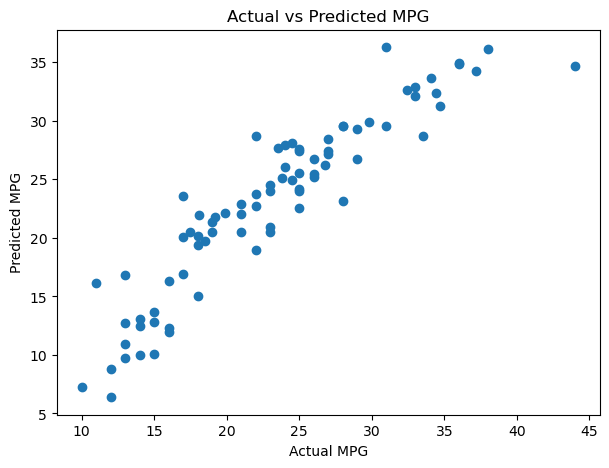

In [18]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG")

plt.show()

In [19]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef

,Feature,Coefficient
0,cylinders,-0.156793
1,displacement,0.014220
2,horsepower,-0.013187
3,weight,-0.006746
4,acceleration,0.068776
5,model_year,0.794960
6,origin,1.322959
